# Matrices for short gamma-ray bursts

**Objective -** To study the observability of an afterglow for each combination of the following parameters : $E_0$, $z$, $\theta_c$, $\theta_w$ and $\theta_{obs}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
from astropy.cosmology import Planck18 as cosmo

## Useful functions

In [2]:
def ObsTime(t, mag):
    index = []
    for i in range(len(mag)-1):
        if mag[i] < 24.5:
            index.append(i)
    if not index:
        return 0
    else:
        dt = (t[max(index)] - t[min(index)])*grb.sec2day
        return dt

In [3]:
def matrix(thetaCore, thetaWing, thetaObs, E, z, n):
    
    Z = {'jetType':     grb.jet.PowerLaw,   # Jet Type
         'specType':    0,                  # Emission Spectrum
         'b':           4,                  # Power Law index
         'thetaObs':    0.25,               # Viewing angle
         'E0':          1.0e52,             # Isotropic-equivalent energy in erg
         'thetaWing':   0.2,                # Truncation angle
         'thetaCore':   0.1,                # Half-opening angle in radians
         'n0':          5.0e-3,             # Circumburst density in cm^{-3}
         'p':           2.2,                # Electron energy distribution index
         'epsilon_e':   0.1,                # epsilon_e
         'epsilon_B':   0.01,               # epsilon_B
         'xi_N':        1.0,                # Fraction of electrons accelerated
         'd_L':         1.0e28,             # Luminosity distance in cm
         'z':           0.01}               # Redshift
    
    obs_time = [[[0 for x in range(len(thetaCore))] for y in range(len(thetaWing))] for z in range(len(thetaObs))]
    Z['E0'] = 1.0*10**E
    Z['z'] = z
    Z['d_L'] = cosmo.luminosity_distance(Z['z']).value*3.08e24
    Z['n0'] = n
    
    for k in range(len(thetaCore)):
        Z['thetaCore'] = thetaCore[k]
        for j in range(len(thetaWing)):
            if thetaCore[k] < thetaWing[j]:
                Z['thetaWing'] = thetaWing[j]
                for i in range(len(thetaObs)):
                    if Z['thetaWing'] + thetaObs[i] < np.pi/2:
                        Z['thetaObs'] = Z['thetaWing'] + thetaObs[i]
                        Fnu = grb.fluxDensity(t, nu, **Z)
                        mag = -2.5 * np.log10(Fnu*1.0e-26) - 48.6
                        if min(mag) < 24.5: # If the afterglow is observable in the first place
                            obs_time[i][j][k] = ObsTime(t,mag)
                        else: # Else the observable time is set to zero
                            obs_time[i][j][k] = 0
                    
    return obs_time

In [4]:
def plot_matrix(obs_time, thetaCore, thetaWing, thetaObs, z, E):
    
    redshift = z
    colors = ['deepskyblue', 'darkgreen', 'royalblue', 'orangered', 'sienna']
    
    fig = plt.figure(figsize=(13.,15.))
    ax = fig.add_subplot(111)

    for k in range(len(thetaCore)):
        x = thetaCore[k]
        for j in range(len(thetaWing)):
            y = thetaWing[j]
            ax.scatter(math.degrees(x), math.degrees(y), s=10, color='k', alpha=1)
            for i in range(len(thetaObs)):
                if thetaWing[j] + thetaObs[i] < np.pi/2:
                    z = thetaWing[j] + thetaObs[i]
                    if obs_time[i][j][k] > 0:
                        #ax.scatter(math.degrees(x), math.degrees(y), label = z, s = (obs_time[i][j][k]*50), facecolors='none', edgecolors=colors[i], alpha=1)
                        #ax.text(math.degrees(x)+0.25, math.degrees(y)-(i*0.5)+0.5, '%.1f' %obs_time[i][j][k], c = colors[i])
                        ax.text(math.degrees(x)+0.2, math.degrees(y)-(i*0.7)+1, '%.1f' %obs_time[i][j][k], c = colors[i], fontsize=13)
                        
    ax.set(title=r'Power-Law Jet : z = %.2f, E = 10$^{%i}$ erg' %(redshift, E))
    ax.set_xlabel(r'$\theta_c$ (°)', fontsize=15)
    ax.set_ylabel(r'$\theta_w$ (°)', fontsize=15)
    plt.plot([0,14.32], [0,14.32], color = 'aquamarine')

    theta_leg = []
    for i in range(len(thetaObs)):
        theta_leg.append(mpatches.Patch(color=colors[i], label=r'$\theta_{obs}$ = $\theta_w$ + %.2f°' %math.degrees(thetaObs[i])))
    ax.legend(handles=theta_leg, bbox_to_anchor=(1.05,0.8), loc="upper left", borderaxespad=0)

    ax.set_xticks(np.degrees(thetaCore))
    ax.set_yticks(np.degrees(thetaWing))

    ax.grid()

## Parameters

For a short GRB, the chosen parameters are :
- $z_{max} = 0.1 \sim 475$ Mpc : the redshift is limited with the limit of detection of LIGO (O4/O5 $\sim 350$ Mpc),
- $n$ between $1$ and $0.001$ cm$^{-3}$ (we took $0.05$ cm$^{-3}$),
- $E$ between 10$^{50}$ erg and 10$^{53}$ erg.

We limit the angles : 
- $\theta_w > \theta_c$, 
- $\theta_{w,max} = 28.65°$,
- $\theta_{c,max} = 14.32°$,

In [5]:
t = np.geomspace(1.0e3, 1.0e10, 300)
nu = 5.0e14 

thetaCore = [0.05, 0.1, 0.15, 0.2, 0.25]
thetaWing = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
thetaObs = [0.1, 0.2, 0.4, 0.6, 0.8]

n = 0.05

## 1. $z = 0.01$ 

In [6]:
z = 0.01

#### 1.1 $E = 10^{50}$ erg

In [7]:
E = 50

In [8]:
obs_time_001_50 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

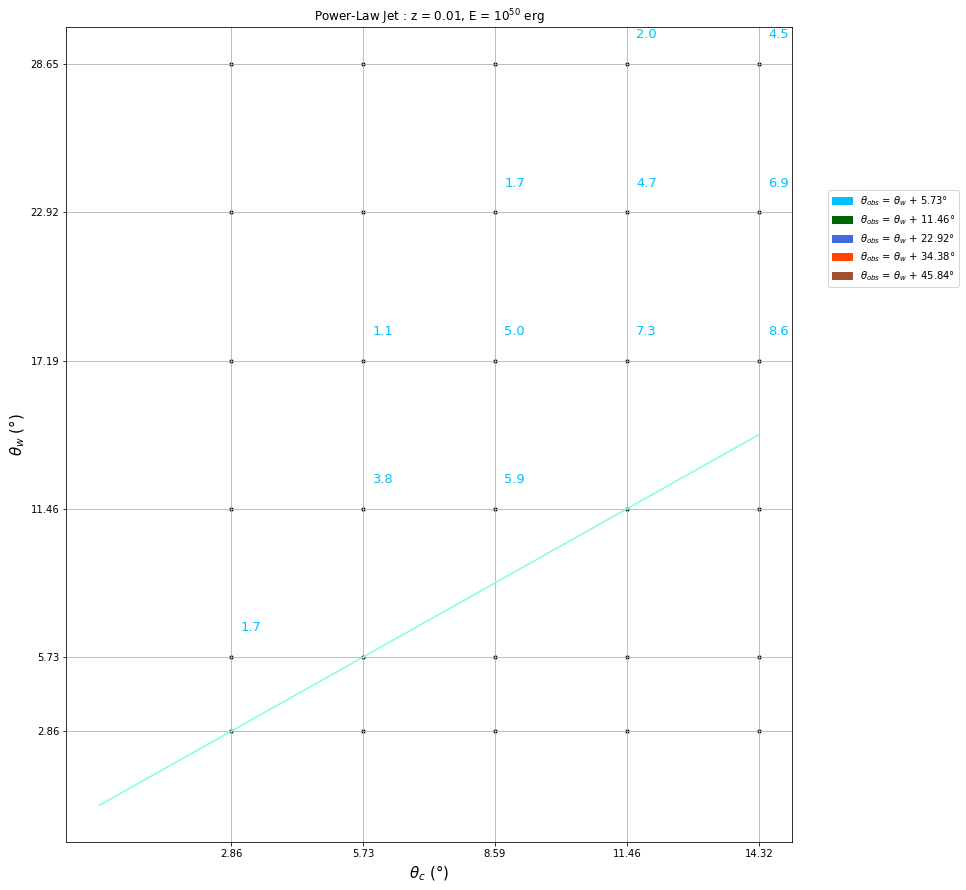

In [9]:
matrix_001_50 = plot_matrix(obs_time_001_50, thetaCore, thetaWing, thetaObs, z, E)

#### 1.2 $E = 10^{51}$ erg

In [10]:
E = 51

In [11]:
obs_time_001_51 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

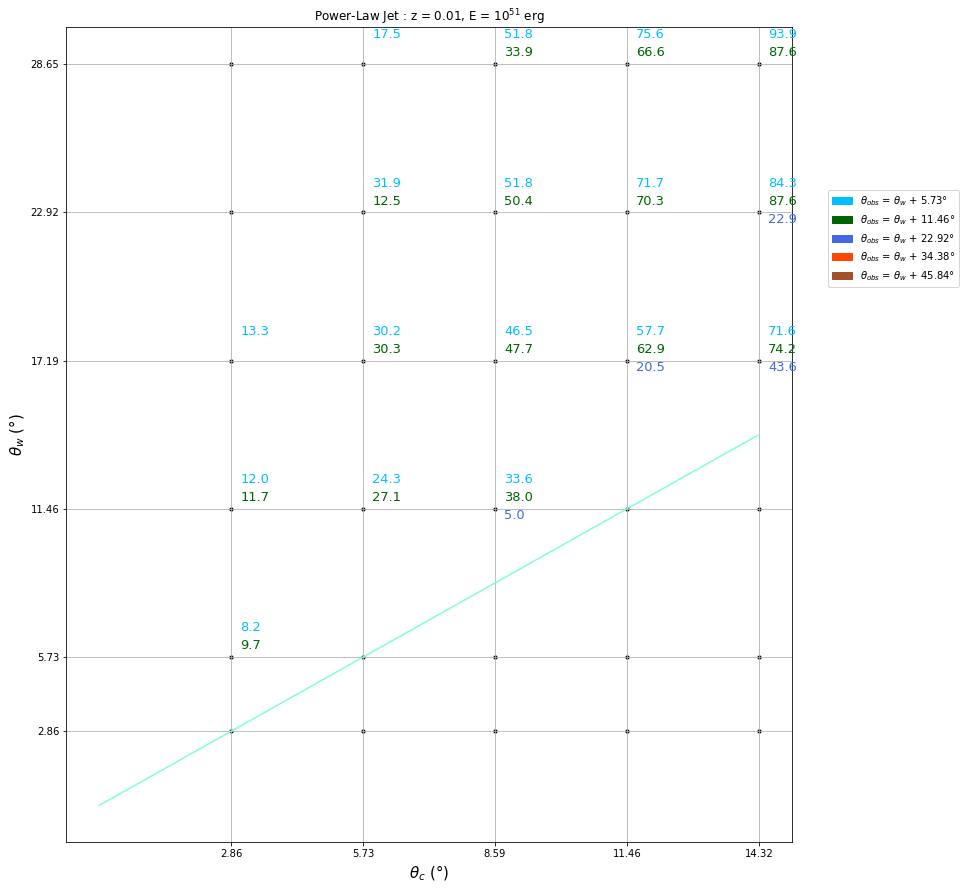

In [12]:
matrix_001_51 = plot_matrix(obs_time_001_51, thetaCore, thetaWing, thetaObs, z, E)

#### 1.3 $E = 10^{52}$ erg

In [13]:
E = 52

In [14]:
obs_time_001_52 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

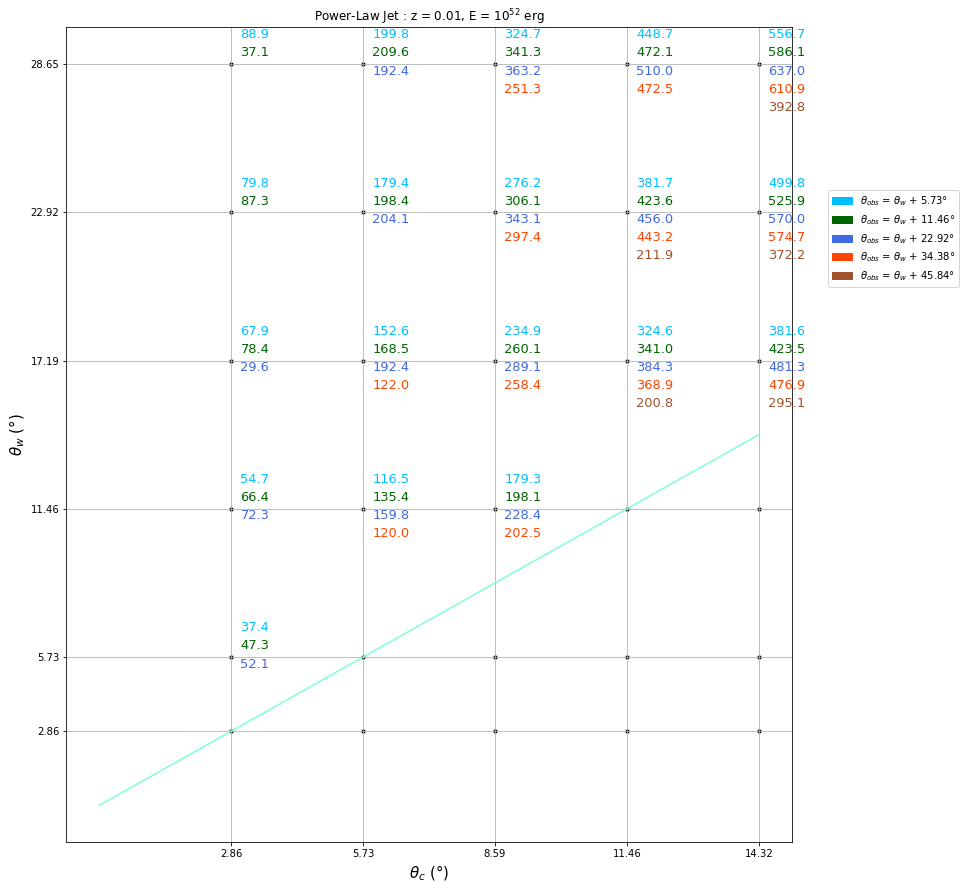

In [15]:
matrix_001_52 = plot_matrix(obs_time_001_52, thetaCore, thetaWing, thetaObs, z, E)

#### 1.3 $E = 10^{53}$ erg

In [16]:
E = 53

In [17]:
obs_time_001_53 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

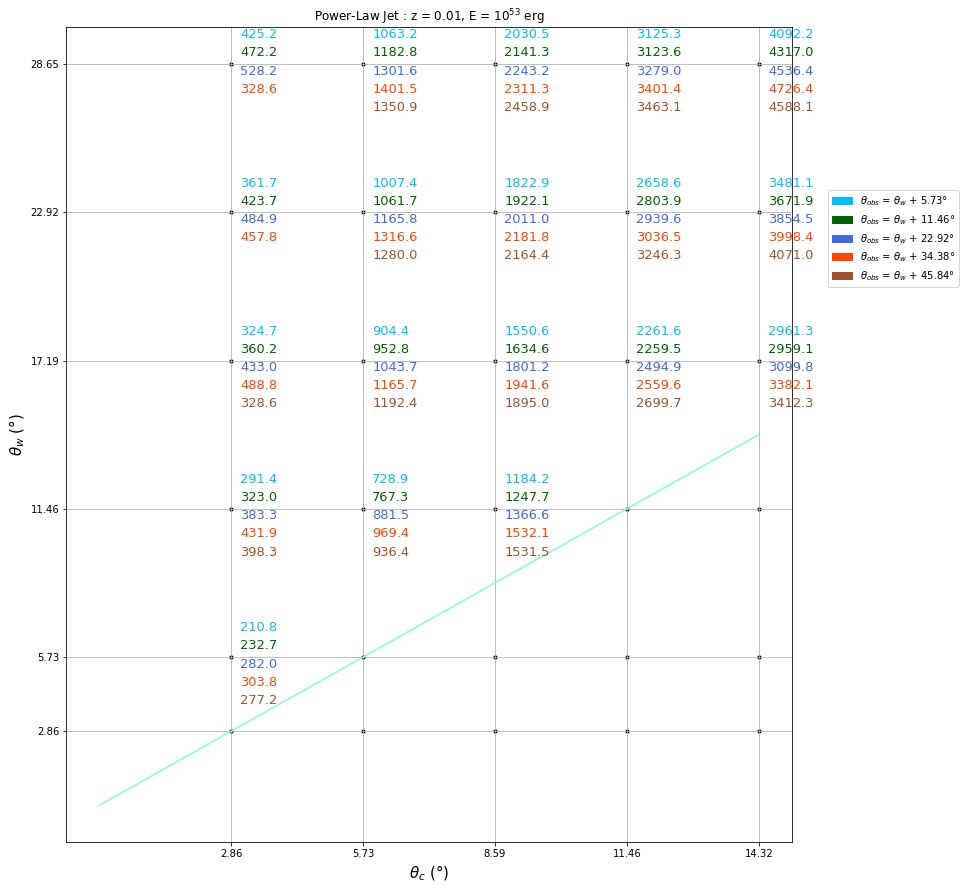

In [18]:
matrix_001_53 = plot_matrix(obs_time_001_53, thetaCore, thetaWing, thetaObs, z, E)

## 2. $z = 0.1$

In [19]:
z = 0.1
n = 0.5

#### 2.1 $E = 10^{50}$ erg

In [20]:
E = 50

In [21]:
obs_time_01_50 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

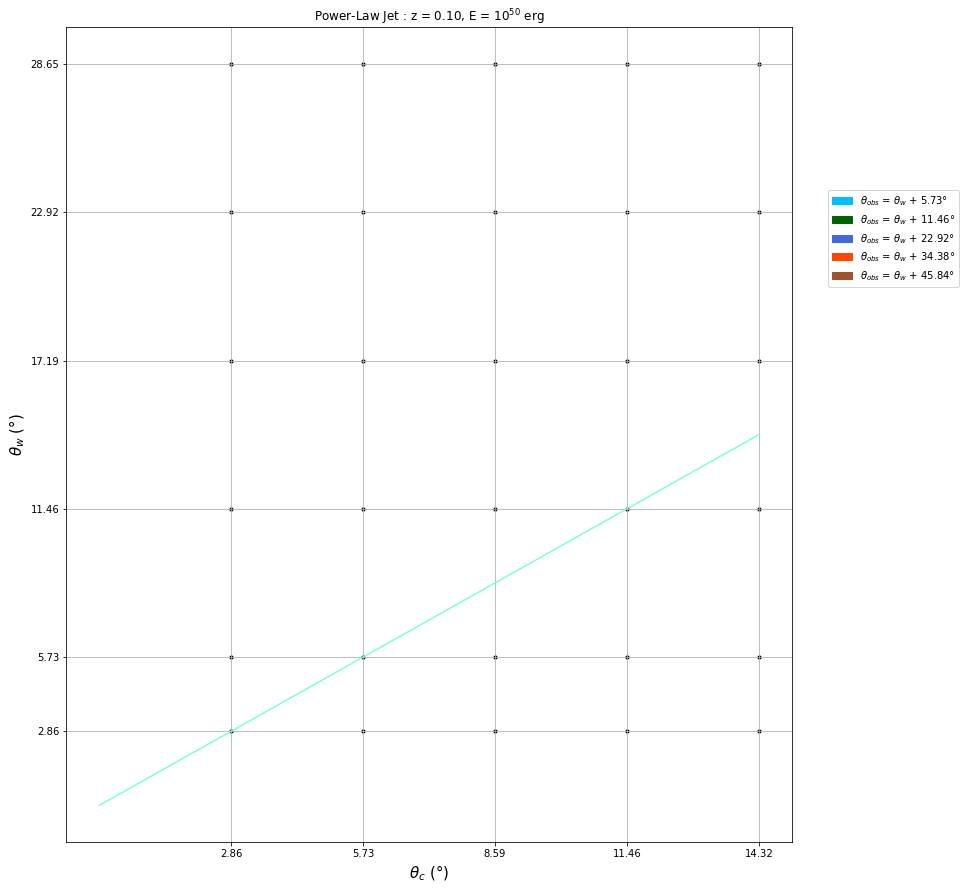

In [22]:
matrix_01_50 = plot_matrix(obs_time_01_50, thetaCore, thetaWing, thetaObs, z, E)

#### 2.2 $E = 10^{51}$ erg

In [23]:
E = 51

In [24]:
obs_time_01_51 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

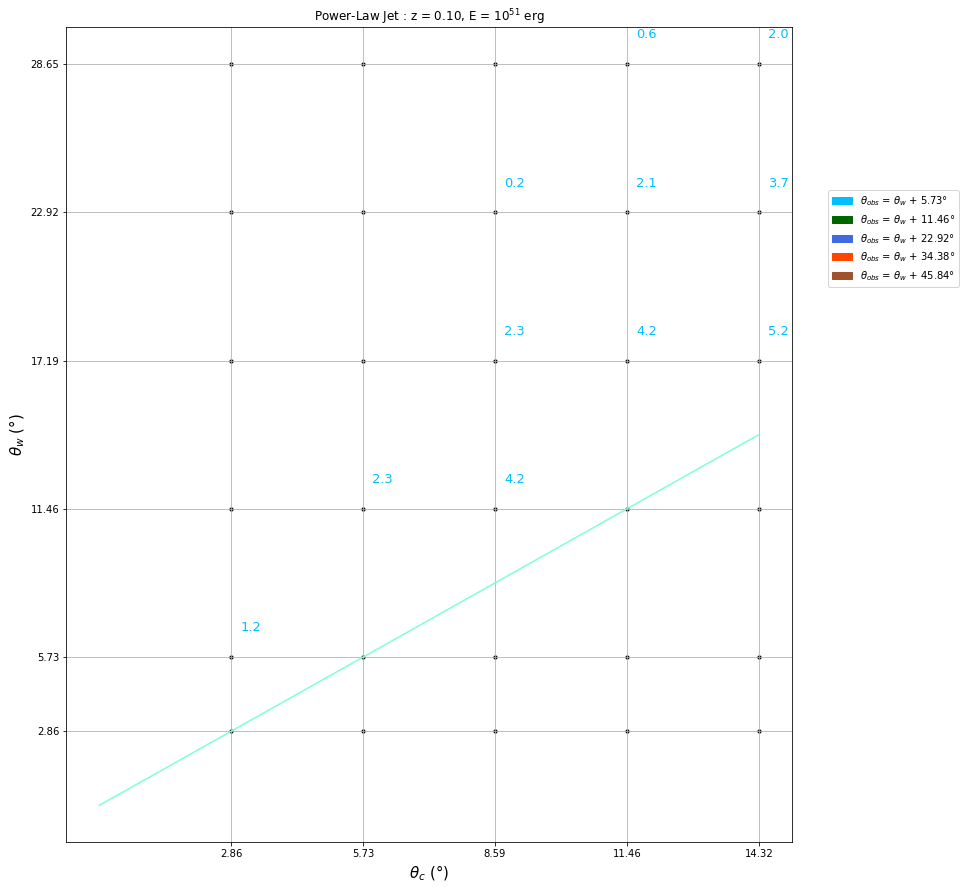

In [25]:
matrix_01_51 = plot_matrix(obs_time_01_51, thetaCore, thetaWing, thetaObs, z, E)

#### 2.3 $E = 10^{52}$ erg

In [26]:
E = 52

In [27]:
obs_time_01_52 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

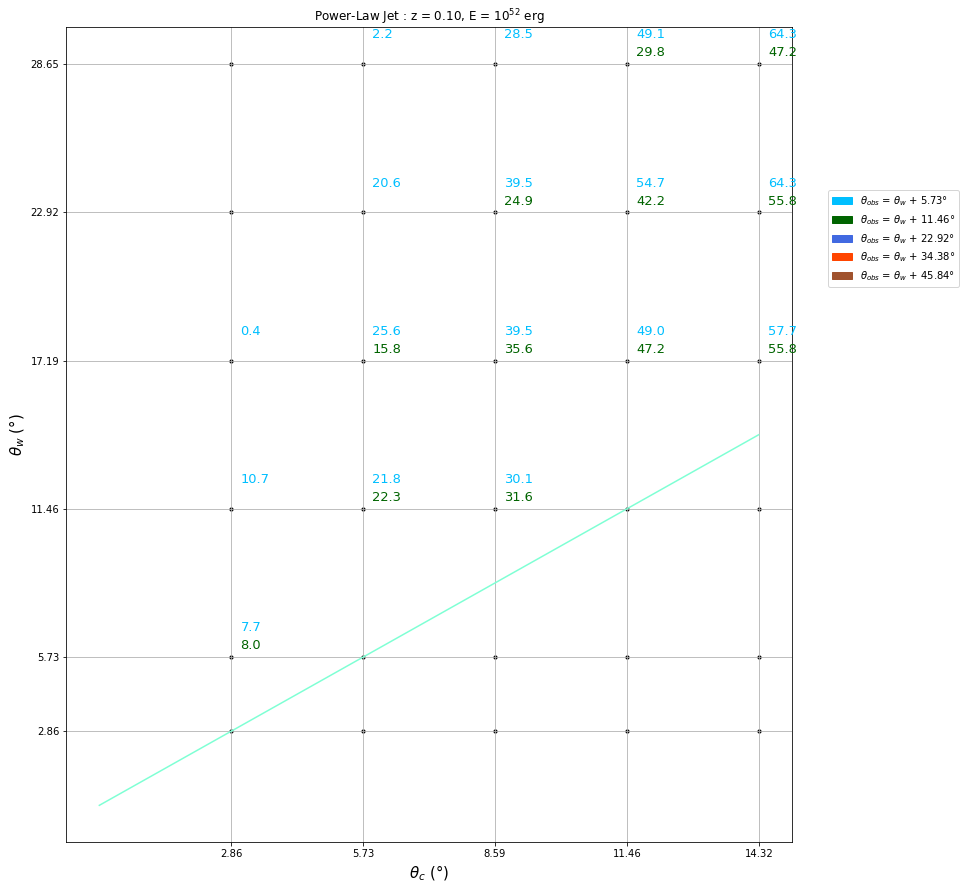

In [28]:
matrix_01_52 = plot_matrix(obs_time_01_52, thetaCore, thetaWing, thetaObs, z, E)

#### 2.3 $E = 10^{53}$ erg

In [29]:
E = 53

In [30]:
obs_time_01_53 = matrix(thetaCore, thetaWing, thetaObs, E, z, n)

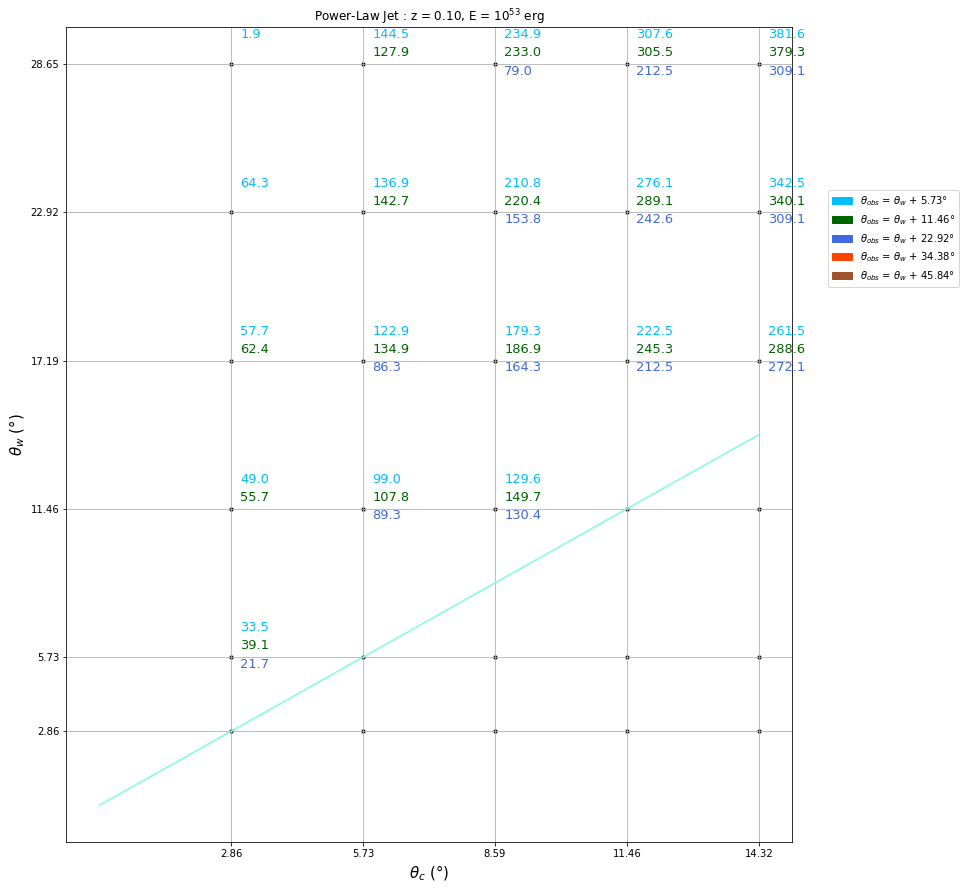

In [31]:
matrix_01_53 = plot_matrix(obs_time_01_53, thetaCore, thetaWing, thetaObs, z, E)